Running 1D Phase Transition Sweep (Unweighted)...


100%|██████████| 15/15 [00:49<00:00,  3.27s/it]


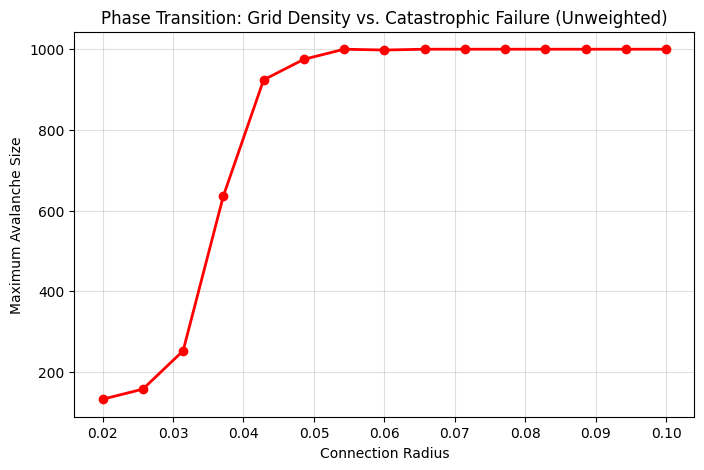

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def run_sim_max_avalanche(radius):
    NUM_NODES, TOL, NOISE, STEPS = 1000, 0.20, 0.8, 2000

    # 1. Build the UNWEIGHTED Network
    G = nx.random_geometric_graph(NUM_NODES, radius=radius)

    # 2. Initialize Nodes
    for node in G.nodes():
        load = np.random.uniform(0, 10)
        G.nodes[node]['load'] = load
        G.nodes[node]['capacity'] = load * (1 + TOL)
        G.nodes[node]['tripped'] = False

    max_avalanche = 0

    # 3. Run Simulation
    for step in range(STEPS):
        for node in G.nodes():
            G.nodes[node]['load'] += (NOISE / 10.0)

        current_avalanche = 0

        while True:
            overloaded = [n for n, d in G.nodes(data=True) if d['load'] > d['capacity'] and not d['tripped']]
            if not overloaded: break

            for node in overloaded:
                overload_amt = G.nodes[node]['load']
                G.nodes[node]['load'] = 0
                G.nodes[node]['tripped'] = True
                current_avalanche += 1

                # EQUAL REDISTRIBUTION (No Weights)
                active_nbrs = [nbr for nbr in G.neighbors(node) if not G.nodes[nbr]['tripped']]
                if active_nbrs:
                    spill = overload_amt / len(active_nbrs)
                    for nbr in active_nbrs:
                        G.nodes[nbr]['load'] += spill

        if current_avalanche > max_avalanche:
            max_avalanche = current_avalanche

        # Reset tripped status for next tick
        for node in G.nodes(): G.nodes[node]['tripped'] = False

    return max_avalanche

# --- THE 1D SWEEP EXECUTION ---
# Sweeping from 0.02 to 0.10 to catch the phase transition
radii = np.linspace(0.02, 0.10, 15)
max_sizes = []

print("Running 1D Phase Transition Sweep (Unweighted)...")
for r in tqdm(radii):
    max_sizes.append(run_sim_max_avalanche(r))

# --- PLOTTING ---
plt.figure(figsize=(8, 5))
plt.plot(radii, max_sizes, marker='o', color='red', linewidth=2)
plt.title("Phase Transition: Grid Density vs. Catastrophic Failure (Unweighted)")
plt.xlabel("Connection Radius")
plt.ylabel("Maximum Avalanche Size")
plt.grid(True, alpha=0.4)
plt.show()